# Understanding the Star Plot (Radar / Spider Chart)

A **star plot** (also called a radar chart or spider chart) displays **multivariate data** on a two-dimensional surface. Each variable gets its own axis radiating from the centre, equally spaced angularly. The value of each variable is plotted along its axis and all values for one observation are connected, forming a polygon. The shape and area of the polygon encodes the overall profile of that observation.

Star plots are used for displaying the **profile of a single case across multiple variables** or comparing a few cases visually.

| Feature | What it reveals |
|---|---|
| Large polygon | High values across many variables |
| Spike on one axis | Dominant in that variable |
| Irregular shape | Mixed strengths and weaknesses |
| Two overlapping polygons | Which entity dominates on which dimensions |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

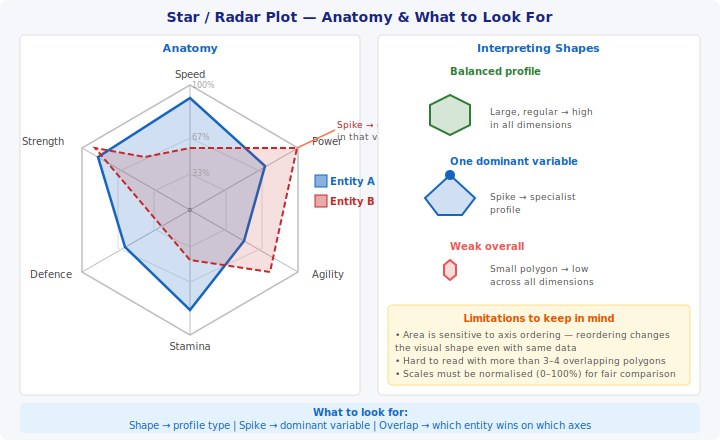

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="440"
     font-family="'Segoe UI', Arial, sans-serif">
  <rect width="720" height="440" fill="#F5F7FA" rx="8"/>
  <text x="360" y="22" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Star / Radar Plot — Anatomy &amp; What to Look For</text>

  <!-- ── LEFT: anatomy panel ── -->
  <rect x="20" y="35" width="340" height="360" fill="white" stroke="#E0E0E0" rx="4"/>
  <text x="190" y="52" text-anchor="middle" font-size="11" font-weight="bold" fill="#1565C0">Anatomy</text>

  <!-- Centre -->
  <circle cx="190" cy="210" r="2" fill="#424242"/>

  <!-- 6 axes at 0°, 60°, 120°, 180°, 240°, 300° -->
  <!-- axis 0: top (90°) — Speed -->
  <line x1="190" y1="210" x2="190" y2="85"  stroke="#BDBDBD" stroke-width="1"/>
  <text x="190" y="78" text-anchor="middle" font-size="10" fill="#424242">Speed</text>
  <!-- axis 1: upper-right (30°) — Power -->
  <line x1="190" y1="210" x2="298" y2="148" stroke="#BDBDBD" stroke-width="1"/>
  <text x="312" y="145" font-size="10" fill="#424242">Power</text>
  <!-- axis 2: lower-right (330°) — Agility -->
  <line x1="190" y1="210" x2="298" y2="272" stroke="#BDBDBD" stroke-width="1"/>
  <text x="312" y="278" font-size="10" fill="#424242">Agility</text>
  <!-- axis 3: bottom (270°) — Stamina -->
  <line x1="190" y1="210" x2="190" y2="335" stroke="#BDBDBD" stroke-width="1"/>
  <text x="190" y="350" text-anchor="middle" font-size="10" fill="#424242">Stamina</text>
  <!-- axis 4: lower-left (210°) — Defence -->
  <line x1="190" y1="210" x2="82" y2="272" stroke="#BDBDBD" stroke-width="1"/>
  <text x="30" y="278" font-size="10" fill="#424242">Defence</text>
  <!-- axis 5: upper-left (150°) — Strength -->
  <line x1="190" y1="210" x2="82" y2="148" stroke="#BDBDBD" stroke-width="1"/>
  <text x="22" y="145" font-size="10" fill="#424242">Strength</text>

  <!-- Grid rings at 33%, 67%, 100% -->
  <!-- 33% ring -->
  <polygon points="190,174 226,191 226,229 190,247 154,229 154,191"
           fill="none" stroke="#E0E0E0" stroke-width="1"/>
  <!-- 67% ring -->
  <polygon points="190,138 262,172 262,248 190,282 118,248 118,172"
           fill="none" stroke="#E0E0E0" stroke-width="1"/>
  <!-- 100% ring (outer) -->
  <polygon points="190,85 298,148 298,272 190,335 82,272 82,148"
           fill="none" stroke="#BDBDBD" stroke-width="1.5"/>

  <!-- Entity A polygon (blue, large) — values: 90, 70, 50, 80, 60, 85 -->
  <!-- as fraction of axis length 125: 0.9=112, 0.7=87, 0.5=62, 0.8=100, 0.6=75, 0.85=106 -->
  <!-- points computed along each axis direction:
       top: (190, 210-112)=(190,98); upper-right: (190+87*sin60, 210-87*cos60)=(190+75,210-44)=(265,166)
       lower-right: (190+62*sin60, 210+62*cos60)=(190+54,210+31)=(244,241)
       bottom: (190,210+100)=(190,310); lower-left: (190-75*sin60,210+75*cos60)=(190-65,210+37)=(125,247)
       upper-left: (190-106*sin60,210-106*cos60)=(190-92,210-53)=(98,157) -->
  <polygon points="190,98 265,166 244,241 190,310 125,247 98,157"
           fill="#1565C0" fill-opacity="0.2" stroke="#1565C0" stroke-width="2.5"/>
  <text x="330" y="185" font-size="10" font-weight="bold" fill="#1565C0">Entity A</text>
  <rect x="315" y="175" width="12" height="12" fill="#1565C0" fill-opacity="0.5" stroke="#1565C0"/>

  <!-- Entity B polygon (red, smaller, different shape) -->
  <!-- values: 50, 90, 75, 40, 85, 55 -->
  <!-- top: 62; ur: 112; lr: 94; bot: 50; ll: 106; ul: 68 -->
  <polygon points="190,148 297,148 270,272 190,260 95,148 145,157"
           fill="#C62828" fill-opacity="0.15" stroke="#C62828" stroke-width="2" stroke-dasharray="6,3"/>
  <text x="330" y="205" font-size="10" font-weight="bold" fill="#C62828">Entity B</text>
  <rect x="315" y="195" width="12" height="12" fill="#C62828" fill-opacity="0.4" stroke="#C62828"/>

  <!-- Annotation: spike on Power axis -->
  <line x1="297" y1="148" x2="335" y2="130" stroke="#FF7043" stroke-width="1.5"/>
  <text x="337" y="128" font-size="9" fill="#B71C1C">Spike → dominant</text>
  <text x="337" y="140" font-size="9" fill="#555">in that variable</text>

  <!-- Scale tick labels -->
  <text x="192" y="176" font-size="8" fill="#9E9E9E">33%</text>
  <text x="192" y="140" font-size="8" fill="#9E9E9E">67%</text>
  <text x="192" y="88"  font-size="8" fill="#9E9E9E">100%</text>

  <!-- ── RIGHT: what to look for panel ── -->
  <rect x="378" y="35" width="322" height="360" fill="white" stroke="#E0E0E0" rx="4"/>
  <text x="539" y="52" text-anchor="middle" font-size="11" font-weight="bold" fill="#1565C0">Interpreting Shapes</text>

  <!-- Shape 1: balanced (large regular hexagon) -->
  <text x="450" y="75" font-size="10" font-weight="bold" fill="#2E7D32">Balanced profile</text>
  <polygon points="450,95 470,105 470,125 450,135 430,125 430,105"
           fill="#2E7D32" fill-opacity="0.2" stroke="#2E7D32" stroke-width="2"/>
  <text x="490" y="115" font-size="9" fill="#555">Large, regular → high</text>
  <text x="490" y="128" font-size="9" fill="#555">in all dimensions</text>

  <!-- Shape 2: spike -->
  <text x="450" y="165" font-size="10" font-weight="bold" fill="#1565C0">One dominant variable</text>
  <polygon points="450,175 475,198 462,215 438,215 425,198"
           fill="#1565C0" fill-opacity="0.2" stroke="#1565C0" stroke-width="2"/>
  <circle cx="450" cy="175" r="5" fill="#1565C0"/>
  <text x="490" y="200" font-size="9" fill="#555">Spike → specialist</text>
  <text x="490" y="213" font-size="9" fill="#555">profile</text>

  <!-- Shape 3: weak overall -->
  <text x="450" y="250" font-size="10" font-weight="bold" fill="#EF5350">Weak overall</text>
  <polygon points="450,260 456,265 456,275 450,280 444,275 444,265"
           fill="#EF5350" fill-opacity="0.2" stroke="#EF5350" stroke-width="2"/>
  <text x="490" y="272" font-size="9" fill="#555">Small polygon → low</text>
  <text x="490" y="285" font-size="9" fill="#555">across all dimensions</text>

  <!-- Limitations note -->
  <rect x="388" y="305" width="302" height="80" fill="#FFF8E1" stroke="#FFE082" rx="4"/>
  <text x="539" y="322" text-anchor="middle" font-size="10" font-weight="bold" fill="#E65100">Limitations to keep in mind</text>
  <text x="395" y="338" font-size="9" fill="#555">• Area is sensitive to axis ordering — reordering changes</text>
  <text x="395" y="351" font-size="9" fill="#555">  the visual shape even with same data</text>
  <text x="395" y="364" font-size="9" fill="#555">• Hard to read with more than 3–4 overlapping polygons</text>
  <text x="395" y="377" font-size="9" fill="#555">• Scales must be normalised (0–100%) for fair comparison</text>

  <!-- Takeaway -->
  <rect x="20" y="403" width="680" height="30" fill="#E3F2FD" rx="4"/>
  <text x="360" y="416" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">What to look for:</text>
  <text x="360" y="429" text-anchor="middle" font-size="10" fill="#1565C0">Shape → profile type   |   Spike → dominant variable   |   Overlap → which entity wins on which axes</text>
</svg>
"""
display(SVG(_svg))

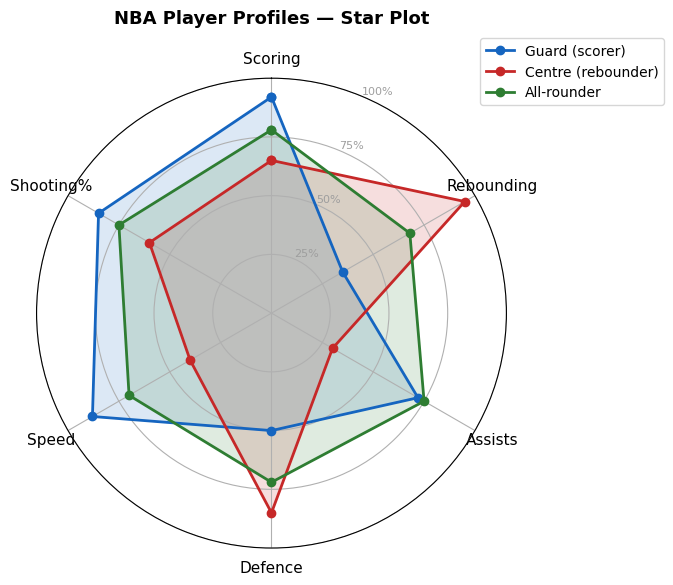

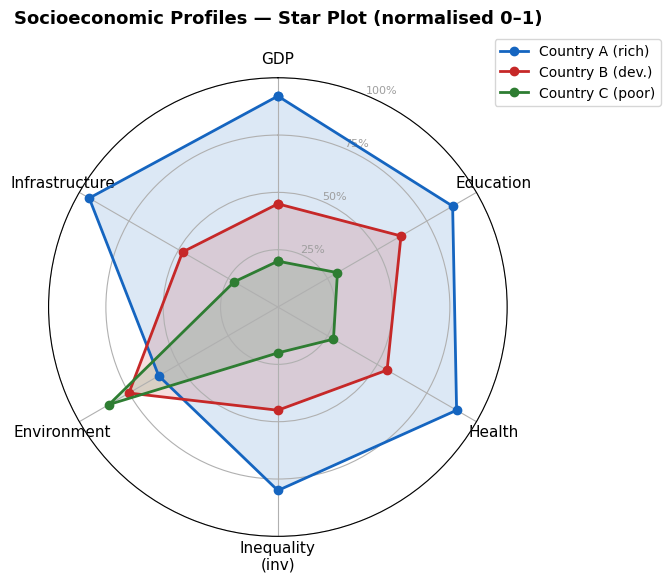

In [3]:
def radar_chart(categories, data_dict, title="Star / Radar Plot"):
    """
    categories: list of variable names
    data_dict:  {label: [values, ...]} — values must be in [0, 1] or normalised
    """
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    colors = ['#1565C0', '#C62828', '#2E7D32', '#E65100', '#6A1B9A']
    for (label, values), color in zip(data_dict.items(), colors):
        vals = list(values) + list(values[:1])
        ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=label)
        ax.fill(angles, vals, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
    ax.yaxis.set_tick_params(labelcolor='#9E9E9E')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
    plt.tight_layout()
    plt.show()

# ── Example 1: NBA player profiles ──
categories = ['Scoring', 'Rebounding', 'Assists', 'Defence', 'Speed', 'Shooting%']
players = {
    'Guard (scorer)':   [0.92, 0.35, 0.72, 0.50, 0.88, 0.85],
    'Centre (rebounder)':[0.65, 0.95, 0.30, 0.85, 0.40, 0.60],
    'All-rounder':      [0.78, 0.68, 0.75, 0.72, 0.70, 0.75],
}
radar_chart(categories, players, "NBA Player Profiles — Star Plot")

# ── Example 2: Country socioeconomic profiles ──
dims = ['GDP', 'Education', 'Health', 'Inequality\n(inv)', 'Environment', 'Infrastructure']
countries = {
    'Country A (rich)': [0.92, 0.88, 0.90, 0.80, 0.60, 0.95],
    'Country B (dev.)': [0.45, 0.62, 0.55, 0.45, 0.75, 0.48],
    'Country C (poor)': [0.20, 0.30, 0.28, 0.20, 0.85, 0.22],
}
radar_chart(dims, countries, "Socioeconomic Profiles — Star Plot (normalised 0–1)")

## Key Takeaways

| | |
|---|---|
| **Best for** | Comparing multivariate profiles for a small number of entities (2–4) |
| **Normalise first** | All axes must be on the same scale (0–1 or z-score) before plotting |
| **Spike** | One axis far out → that variable dominates for that entity |
| **Area** | Larger polygon area → higher overall across all dimensions |
| **Axis ordering matters** | Adjacent axes appear to trade off — try different orderings |
| **Limitation** | Hard to read with many overlapping polygons or many axes (>8) |
| **vs parallel coordinates** | Parallel coordinates are better for many entities; star plot is better for 2–4 |
| **vs heatmap** | Heatmap scales to many entities; star plot is more intuitive for a few |